# fMRI Data Loading and Normalization in Python 
**Contributors: original code: Manoj Kumar, adapted by Elizabeth McDevitt and later by James Antony**   

### Goal of this script
 1. load the viewing run of fMRI data into python, locally
 2. create a brain mask - ses01_brain
 3. perform spatial smoothing using SUSAN smooth
 4. trim volumes, adjust for confound regressors, and z-score the data
     - save volume as _norm.nii.gz

In [12]:
# 'ipynby' is how I switch between running in jupyter notebooks and on our computing cluster. 
ipynby=1 #python notebook or not
if ipynby==0: #jargon for // scripting
    import argparse
    parser = argparse.ArgumentParser()
    parser.add_argument('-subject', type=str)
    args = parser.parse_args()
    print(args.subject)
    subject=args.subject
elif ipynby==1: #if local
    subject=1
print(len(str(subject)))
if len(str(subject))==1:
    sub ='sub-0'+str(subject)
else:
    sub ='sub-'+str(subject)
subS = str(int(subject))
ses = 'ses-01'
task='view'
n_trunc=0 # #volumes to trim/truncate
filtcutoff=140 #high-pass filter - used previously but not here
print(sub)
fwhmval=2 #3
n_runs=5

1
sub-01


In [13]:
#import packages
import os
import sys 
import time
import copy
import shutil
import warnings
import scipy.io
import numpy as np
import pandas as pd
import nibabel as nib
from scipy import stats
from nilearn import image
import matplotlib.pyplot as plt 
from sklearn import preprocessing
from nilearn.plotting import plot_roi
from nilearn.plotting import plot_epi
from nilearn.plotting import plot_anat
from nilearn.image import new_img_like
from nilearn.masking import apply_mask
from nilearn.image.image import mean_img
from nilearn.image import resample_to_img
from sklearn import datasets, linear_model
from nilearn.masking import intersect_masks
from nilearn.masking import compute_epi_mask
from nilearn.masking import compute_brain_mask
from nilearn.datasets import load_mni152_template
from nilearn.input_data import NiftiMasker,  MultiNiftiMasker
from niflow.nipype1.workflows.fmri.fsl.preprocess import create_susan_smooth 
#from nipype.workflows.fmri.fsl import create_susan_smooth 

if not sys.warnoptions:
    warnings.simplefilter("ignore")

if ipynby==1: #if local
    %matplotlib inline 
    %autosave 30

Autosaving every 30 seconds


In [14]:
# load some helper functions and import data / settings
import fr_utils
from fr_utils import load_fr_epi_data, load_fr_mask, mask_data, load_data
from fr_utils import fr_dir, fr_bids_dir, fr_TR, fr_hrf_lag, run_names
print('TASK:', task)
print('LIST OF TASKS:', run_names)
task_index = run_names.index(task)
print('task index:', task_index)
print('')
fr_dir = '/Users/jamesantony/Desktop/friends_fmri/data/'
fr_bids_dir = '/Users/jamesantony/Desktop/friends_fmri/data/bids/RangaL/RangaL_Antony/friends/'

#directories
bold_dir=fr_bids_dir + 'derivatives/fmriprep/%s/%s/func/' % (sub, ses)
#anat_dir=fr_dir + 'data/extra/T1w_defaced/'
anat_dir=fr_bids_dir + '%s/%s/anat/' % (sub, ses)
anat_fmriprep_dir=fr_bids_dir + 'derivatives/fmriprep/%s/%s/anat/' % (sub,ses)
out_dir_outer= fr_bids_dir + 'derivatives/firstlevel/%s/' % sub
mask_fold = fr_bids_dir + 'derivatives/firstlevel/%s/%s/masks/' % (sub,ses)
ec_anat_dir= fr_bids_dir + 'derivatives/firstlevel/%s/%s/native_masks/manual/' % (sub,ses)
ses1_dir=fr_bids_dir + 'derivatives/fmriprep/%s/ses-01/func/' % sub
roi_dir=fr_dir+'bids/RangaL/RangaL_Antony/rois/'

if not os.path.exists(out_dir_outer):
    os.makedirs(out_dir_outer)
out_dir=out_dir_outer+'ses-01/'
if not os.path.exists(out_dir):
    os.makedirs(out_dir)
if not os.path.exists(mask_fold):
    os.makedirs(mask_fold)

analysis_dir=fr_dir+'analysis/'

print('num runs = %s' % (n_runs))
print('bids dir = %s' % (fr_bids_dir))
print('anat dir = %s' % (anat_dir))
print('subj dir = %s' % (bold_dir))
print('out dir = %s' % (out_dir))
print('ses1 dir = %s' % (ses1_dir))
print('ROI dir: %s' %roi_dir)
print('mask fold = %s' % (mask_fold))
print('TR = %s seconds' % (fr_TR))
print('trim %d volumes from each run' % (n_trunc))

TASK: view
LIST OF TASKS: ['pre', 'view', 'recall', 'post', 'srm']
task index: 1

num runs = 5
bids dir = /Users/jamesantony/Desktop/friends_fmri/data/bids/RangaL/RangaL_Antony/friends/
anat dir = /Users/jamesantony/Desktop/friends_fmri/data/bids/RangaL/RangaL_Antony/friends/sub-01/ses-01/anat/
subj dir = /Users/jamesantony/Desktop/friends_fmri/data/bids/RangaL/RangaL_Antony/friends/derivatives/fmriprep/sub-01/ses-01/func/
out dir = /Users/jamesantony/Desktop/friends_fmri/data/bids/RangaL/RangaL_Antony/friends/derivatives/firstlevel/sub-01/ses-01/
ses1 dir = /Users/jamesantony/Desktop/friends_fmri/data/bids/RangaL/RangaL_Antony/friends/derivatives/fmriprep/sub-01/ses-01/func/
ROI dir: /Users/jamesantony/Desktop/friends_fmri/data/bids/RangaL/RangaL_Antony/rois/
mask fold = /Users/jamesantony/Desktop/friends_fmri/data/bids/RangaL/RangaL_Antony/friends/derivatives/firstlevel/sub-01/ses-01/masks/
TR = 2 seconds
trim 0 volumes from each run


In [15]:
#Select confounds and trim volumes from confounds file
#Choose the desired confounds from the confounds_regressors.tsv file from fmriprep, 
#trim the columns corresponding to trimmed volumes, and save as a .txt file. 
#note in 2020, the output file changed from _regressors to _timeseries
starttime = time.time()
confounds,confounds_all,mc_all,ntr=[],[],[],np.zeros((n_runs))
print('Number of runs:', run_names[task_index], n_runs)

for r in range(n_runs):
    fname='_ses-01_task-%s_desc-confounds_timeseries.tsv' % (run_names[r])
    confounds = pd.read_csv(ses1_dir + sub + fname,  sep='\t', header=(0))
    #'framewise_displacement' because it had nan values if we didn't truncate...
    #confounds_selected=confounds[['trans_x','trans_y','trans_z','rot_x','rot_y','rot_z','a_comp_cor_00','a_comp_cor_01','a_comp_cor_02','a_comp_cor_03','a_comp_cor_04','a_comp_cor_05']][n_trunc:]
    confounds_selected=confounds[['trans_x','trans_y','trans_z','rot_x','rot_y','rot_z','a_comp_cor_00','a_comp_cor_01','a_comp_cor_02','a_comp_cor_03','a_comp_cor_04','a_comp_cor_05','framewise_displacement']][n_trunc:]
    confounds_selected=pd.DataFrame(confounds_selected)
    sn=out_dir + sub + '_ses-01_task-%s_confounds_selected.txt' %run_names[r]
    print(sn)
    confounds_selected.to_csv(sn, index=False, sep='\t', mode='w')
    ntr[r]=confounds_selected.shape[0]
    if r==0:
        confounds_pre=confounds_selected
    elif r==1:
        confounds_view=confounds_selected
    elif r==2:
        confounds_recall=confounds_selected
    elif r==3:
        confounds_post=confounds_selected
    elif r==4:
        confounds_srm=confounds_selected
print(confounds_pre)
print('TRs / run: %s' %ntr)

Number of runs: view 5
/Users/jamesantony/Desktop/friends_fmri/data/bids/RangaL/RangaL_Antony/friends/derivatives/firstlevel/sub-01/ses-01/sub-01_ses-01_task-pre_confounds_selected.txt
/Users/jamesantony/Desktop/friends_fmri/data/bids/RangaL/RangaL_Antony/friends/derivatives/firstlevel/sub-01/ses-01/sub-01_ses-01_task-view_confounds_selected.txt
/Users/jamesantony/Desktop/friends_fmri/data/bids/RangaL/RangaL_Antony/friends/derivatives/firstlevel/sub-01/ses-01/sub-01_ses-01_task-recall_confounds_selected.txt
/Users/jamesantony/Desktop/friends_fmri/data/bids/RangaL/RangaL_Antony/friends/derivatives/firstlevel/sub-01/ses-01/sub-01_ses-01_task-post_confounds_selected.txt
/Users/jamesantony/Desktop/friends_fmri/data/bids/RangaL/RangaL_Antony/friends/derivatives/firstlevel/sub-01/ses-01/sub-01_ses-01_task-srm_confounds_selected.txt
      trans_x   trans_y   trans_z     rot_x     rot_y     rot_z  \
0    0.029995 -0.042680 -0.021626  0.001508  0.001418 -0.000757   
1    0.030937 -0.167671  0.1

## Create average mask <a id="load_fmri"></a>

[[  -2.    0.    0.   90.]
 [   0.    2.    0. -126.]
 [   0.    0.    2.  -72.]
 [   0.    0.    0.    1.]]
/Users/jamesantony/Desktop/friends_fmri/data/bids/RangaL/RangaL_Antony/friends/derivatives/fmriprep/sub-01/ses-01/anat/sub-01_ses-01_space-MNI152NLin6Asym_desc-brain_mask.nii.gz
/Users/jamesantony/Desktop/friends_fmri/data/bids/RangaL/RangaL_Antony/friends/derivatives/firstlevel/sub-01/ses-01/masks/sub-01_ses-01_brain.nii.gz


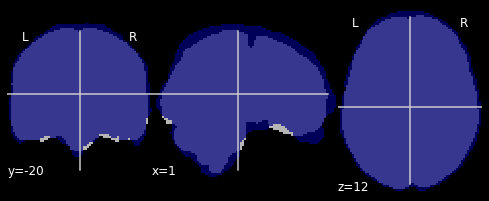

In [16]:
#down-size to 3 mm voxels and create average mask
#note change in MNI space here v 2020: https://fmriprep.org/en/stable/spaces.html
mask_imgs=[]
for run in range(n_runs):
    #mask_name = ses1_dir + sub + '_ses-01_task-%s_space-MNI152NLin2009cAsym_desc-brain_mask.nii.gz' %(run_names[run])
    mask_name = ses1_dir + sub + '_ses-01_task-%s_space-MNI152NLin6Asym_desc-brain_mask.nii.gz' %(run_names[run])
    mask_imgs.append(mask_name)

mni_name=roi_dir+'MNI152_T1_2mm_brain.nii'
template = nib.load(mni_name)
#i=np.eye(3)*2
#template =image.resample_img(template, target_affine=i) 

# intersect 3 view brain masks, binarize
avg_mask=intersect_masks(mask_imgs, threshold=0.5, connected=True)
avg_mask = resample_to_img(avg_mask, template)
thresha=avg_mask.dataobj>-10000
thresh=avg_mask.dataobj>0.5
avg_mask.dataobj[thresha] = 0
avg_mask.dataobj[thresh] = 1
dimsize=avg_mask.header.get_zooms()
affine_mat = avg_mask.affine
print(affine_mat)

#plot average brain
t1_file = anat_fmriprep_dir + sub + '_' + ses + '_space-MNI152NLin6Asym_desc-brain_mask.nii.gz' #2009c
print(t1_file)
t1_img = image.load_img(t1_file)
t1_img = resample_to_img(t1_img, template)
if ipynby==1:
    plot_roi(avg_mask, bg_img=t1_img)

output_name_mask = mask_fold + '%s_%s_brain.nii.gz' % (sub, ses)
print(output_name_mask)# Save the mask
hdr = avg_mask.header  # get a handle for the .nii file's header
hdr.set_zooms((dimsize[0], dimsize[1], dimsize[2]))
nib.save(avg_mask, output_name_mask)

In [17]:
# create an average mask in NATIVE space and use below
runthis=0
if runthis:
    mask_imgs_n=[]
    for run in range(n_runs): 
        mask_name = ses1_dir + sub + '_ses-01_task-%s_space-T1w_desc-brain_mask.nii.gz' %(run_names[run])
        mask_imgs_n.append(mask_name)

    avg_mask_n=intersect_masks(mask_imgs_n, threshold=0.1, connected=True)
    print(avg_mask_n)
    avg_mask_n = resample_to_img(avg_mask_n, template)
    thresha=avg_mask_n.dataobj>-10000
    thresh=avg_mask_n.dataobj>0.1
    avg_mask_n.dataobj[thresha] = 0
    avg_mask_n.dataobj[thresh] = 1
    dimsize=avg_mask_n.header.get_zooms()
    affine_mat_n = avg_mask_n.affine
    print(affine_mat_n)

    #plot average brain
    t1_file_n = anat_fmriprep_dir + sub + '_' + ses + '_desc-brain_mask.nii.gz' #T1w
    print(t1_file_n)
    t1_img_n = image.load_img(t1_file_n)
    t1_img_n = resample_to_img(t1_img_n, template)
    if ipynby==1:
        plot_roi(avg_mask_n, bg_img=t1_img_n)

    output_name_mask_n = mask_fold + '%s_%s_brain_native.nii.gz' % (sub, ses)
    print(output_name_mask_n)# Save the mask
    hdr = avg_mask_n.header  # get a handle for the .nii file's header
    hdr.set_zooms((dimsize[0], dimsize[1], dimsize[2]))
    nib.save(avg_mask_n, output_name_mask_n)

## Perform spatial smoothing <a id="load_fmri"></a>

In [18]:
#function for smoothing
def mod_smooth(in_file, mask_file, fwhm, smooth_type):
    import nipype.interfaces.fsl as fsl
    import nipype.interfaces.freesurfer as fs
    import os
    if smooth_type == 'susan':
        if fwhm == 0:
            return in_file
        smooth = create_susan_smooth()
        smooth.base_dir = out_dir #os.getcwd()
        smooth.inputs.inputnode.fwhm = fwhm
        smooth.inputs.inputnode.mask_file = mask_file
        smooth.inputs.inputnode.in_files = in_file
        res = smooth.run()
        smoothed_file=[] #smoothed_file = res.outputs.outputnode.smoothed_files
    return smoothed_file

In [19]:
#first in native space...
#Load data, truncate, and smooth
runthis=0
if runthis:
    epi_trunc=[]
    #source below:
    #https://github.com/INCF/BrainImagingPipelines/blob/master/bips/workflows/gablab/wips/scripts/modular_nodes.py
    print('Number of runs:', n_runs)

    for run in range(n_runs):#lastrun+1
        out_smooth=(out_dir + '%s_ses-01_task-%s_space-T1w_desc-preproc_bold_trim%d_smooth%d.nii.gz' % (sub,run_names[run],n_trunc,fwhmval))
        #out_smooth=(out_dir + '%s_ses-01_task-%s_space-T1w_desc-preproc9999_bold_trim%d_smooth%d.nii.gz' % (sub,run_names[run],n_trunc,fwhmval))
        if os.path.exists(out_smooth): #If the file exists, skip this step
            print('file exists!')
            proceeeeed=[]

            epi_data0=nib.load(out_smooth)
            epi_data0=resample_to_img(epi_data0, template)
            epi0=epi_data0.get_fdata()

            #truncate
            epi_trunc0 =np.zeros((epi_data0.shape[0], epi_data0.shape[1], epi_data0.shape[2], epi_data0.shape[3]-n_trunc))
            epi_trunc0[:, :, :, :] = epi0[:,:,:,n_trunc:]

            print(epi_data0.shape, '  ', epi_trunc0.shape)
            dimsize=epi_data0.header.get_zooms()
            #print(dimsize)
            orig_dimsize=dimsize

            affine_mat_n = epi_data0.affine  # What is the orientation of the data
            print(affine_mat_n)
        else:
            print('no file, create!')
            epi_file0=ses1_dir + sub + '_ses-01_task-%s_space-T1w_desc-preproc_bold.nii.gz' % (run_names[run])
            epi_data0=nib.load(epi_file0)
            epi_data0=resample_to_img(epi_data0, template)# JWA, August 25 change
            epi0=epi_data0.get_fdata()

            #truncate
            epi_trunc0 =np.zeros((epi_data0.shape[0], epi_data0.shape[1], epi_data0.shape[2], epi_data0.shape[3]-n_trunc))
            epi_trunc0[:, :, :, :] = epi0[:,:,:,n_trunc:]

            print(epi_data0.shape, '  ', epi_trunc0.shape)
            dimsize=epi_data0.header.get_zooms()
            #print(dimsize)
            orig_dimsize=dimsize

            affine_mat_n = epi_data0.affine  # What is the orientation of the data
            print(affine_mat_n)

            # Save the volume
            output_name = (out_dir + '%s_ses-01_task-%s_space-T1w_desc-preproc_bold_trim%d.nii.gz' % (sub,run_names[run], n_trunc))

            bold_nii = nib.Nifti1Image(epi_trunc0, affine_mat_n)
            hdr = bold_nii.header  # get a handle for the .nii file's header
            hdr.set_zooms((dimsize[0], dimsize[1], dimsize[2], dimsize[3]))
            nib.save(bold_nii, output_name)

            # smooth with susan 
            smoothed_file = mod_smooth(output_name,output_name_mask_n,fwhmval, 'susan')

            #move file
            in_smooth=(out_dir+'susan_smooth/smooth/mapflow/_smooth0/' + '%s_ses-01_task-%s_space-T1w_desc-preproc_bold_trim%d_smooth.nii.gz' % (sub, run_names[run], n_trunc))
            out_smooth=(out_dir + '%s_ses-01_task-%s_space-T1w_desc-preproc_bold_trim%d_smooth%d.nii.gz' % (sub, run_names[run], n_trunc,fwhmval))
            os.rename(in_smooth,out_smooth)

In [20]:
#repeat smoothing for standard space data
#Load data, resample to 3 mm, truncate, and smooth
epi_trunc=[]
#source below:
#https://github.com/INCF/BrainImagingPipelines/blob/master/bips/workflows/gablab/wips/scripts/modular_nodes.py
print('Number of runs:', n_runs)

for run in range(n_runs):#lastrun+1
    out_smooth=(out_dir + '%s_ses-01_task-%s_space-MNI152NLin6Asym_desc-preproc_bold_trim%d_smooth%d.nii.gz' % (sub,run_names[run],n_trunc,fwhmval))
    #out_smooth=(out_dir + '%s_ses-01_task-%s_space-MNI152NLin6Asym_desc-preproc9999_bold_trim%d_smooth%d.nii.gz' % (sub,run_names[run],n_trunc,fwhmval))
    if os.path.exists(out_smooth): #If the file exists, skip this step
        print('file exists!')
        proceeeeed=[]

        epi_data=nib.load(out_smooth)
        epi_data=resample_to_img(epi_data, template)
        epi=epi_data.get_fdata()

        #truncate
        epi_trunc =np.zeros((epi_data.shape[0], epi_data.shape[1], epi_data.shape[2], epi_data.shape[3]-n_trunc))
        epi_trunc[:, :, :, :] = epi[:,:,:,n_trunc:]

        print(epi_data.shape, '  ', epi_trunc.shape)
        dimsize=epi_data.header.get_zooms()
        #print(dimsize)
        orig_dimsize=dimsize

        affine_mat = epi_data.affine  # What is the orientation of the data
        print(affine_mat)
    else:
        print('no file, create!')
        epi_file=ses1_dir + sub + '_ses-01_task-%s_space-MNI152NLin6Asym_desc-preproc_bold.nii.gz' % (run_names[run])
        epi_data=nib.load(epi_file)
        epi_data=resample_to_img(epi_data, template)# JWA, August 25 change
        epi=epi_data.get_fdata()

        #truncate
        epi_trunc =np.zeros((epi_data.shape[0], epi_data.shape[1], epi_data.shape[2], epi_data.shape[3]-n_trunc))
        epi_trunc[:, :, :, :] = epi[:,:,:,n_trunc:]

        print(epi_data.shape, '  ', epi_trunc.shape)
        dimsize=epi_data.header.get_zooms()
        #print(dimsize)
        orig_dimsize=dimsize

        affine_mat = epi_data.affine  # What is the orientation of the data
        print(affine_mat)

        # Save the volume
        output_name = (out_dir + '%s_ses-01_task-%s_space-MNI152NLin6Asym_desc-preproc_bold_trim%d.nii.gz' % (sub,run_names[run], n_trunc))

        bold_nii = nib.Nifti1Image(epi_trunc, affine_mat)
        hdr = bold_nii.header  # get a handle for the .nii file's header
        hdr.set_zooms((dimsize[0], dimsize[1], dimsize[2], dimsize[3]))
        nib.save(bold_nii, output_name)

        # smooth with susan 
        smoothed_file = mod_smooth(output_name,output_name_mask,fwhmval, 'susan')

        #move file
        in_smooth=(out_dir+'susan_smooth/smooth/mapflow/_smooth0/' + '%s_ses-01_task-%s_space-MNI152NLin6Asym_desc-preproc_bold_trim%d_smooth.nii.gz' % (sub, run_names[run], n_trunc))
        out_smooth=(out_dir + '%s_ses-01_task-%s_space-MNI152NLin6Asym_desc-preproc_bold_trim%d_smooth%d.nii.gz' % (sub, run_names[run], n_trunc,fwhmval))
        os.rename(in_smooth,out_smooth)

Number of runs: 5
no file, create!
(91, 109, 91, 134)    (91, 109, 91, 134)
[[  -2.    0.    0.   90.]
 [   0.    2.    0. -126.]
 [   0.    0.    2.  -72.]
 [   0.    0.    0.    1.]]
260607-08:46:57,415 nipype.workflow INFO:
	 Workflow susan_smooth settings: ['check', 'execution', 'logging', 'monitoring']
260607-08:46:57,421 nipype.workflow INFO:
	 Running serially.
260607-08:46:57,426 nipype.workflow INFO:
	 [Node] Setting-up "_median0" in "/Users/jamesantony/Desktop/friends_fmri/data/bids/RangaL/RangaL_Antony/friends/derivatives/firstlevel/sub-01/ses-01/susan_smooth/median/mapflow/_median0".
260607-08:46:57,429 nipype.workflow INFO:
	 [Node] Executing "_median0" <nipype.interfaces.fsl.utils.ImageStats>
260607-08:47:05,513 nipype.interface INFO:
	 stdout 2026-06-07T08:47:05.513007:5343.119629 
260607-08:47:05,728 nipype.workflow INFO:
	 [Node] Finished "_median0", elapsed time 8.297945s.
260607-08:47:05,737 nipype.workflow INFO:
	 [Node] Setting-up "_mask0" in "/Users/jamesantony/De

260607-09:23:12,570 nipype.workflow INFO:
	 [Node] Outdated cache found for "susan_smooth.mask".
260607-09:23:12,575 nipype.workflow INFO:
	 [Node] Setting-up "_mask0" in "/Users/jamesantony/Desktop/friends_fmri/data/bids/RangaL/RangaL_Antony/friends/derivatives/firstlevel/sub-01/ses-01/susan_smooth/mask/mapflow/_mask0".
260607-09:23:12,575 nipype.workflow INFO:
	 [Node] Outdated cache found for "_mask0".
260607-09:23:12,844 nipype.workflow INFO:
	 [Node] Executing "_mask0" <nipype.interfaces.fsl.utils.ImageMaths>
260607-09:23:33,273 nipype.workflow INFO:
	 [Node] Finished "_mask0", elapsed time 20.426649s.
260607-09:23:33,279 nipype.workflow INFO:
	 [Node] Outdated cache found for "susan_smooth.meanfunc2".
260607-09:23:33,283 nipype.workflow INFO:
	 [Node] Setting-up "_meanfunc20" in "/Users/jamesantony/Desktop/friends_fmri/data/bids/RangaL/RangaL_Antony/friends/derivatives/firstlevel/sub-01/ses-01/susan_smooth/meanfunc2/mapflow/_meanfunc20".
260607-09:23:33,285 nipype.workflow INFO:


260607-09:33:28,397 nipype.workflow INFO:
	 [Node] Setting-up "_mask0" in "/Users/jamesantony/Desktop/friends_fmri/data/bids/RangaL/RangaL_Antony/friends/derivatives/firstlevel/sub-01/ses-01/susan_smooth/mask/mapflow/_mask0".
260607-09:33:28,398 nipype.workflow INFO:
	 [Node] Outdated cache found for "_mask0".
260607-09:33:28,413 nipype.workflow INFO:
	 [Node] Executing "_mask0" <nipype.interfaces.fsl.utils.ImageMaths>
260607-09:33:55,847 nipype.workflow INFO:
	 [Node] Finished "_mask0", elapsed time 27.432579s.
260607-09:33:55,853 nipype.workflow INFO:
	 [Node] Outdated cache found for "susan_smooth.meanfunc2".
260607-09:33:55,857 nipype.workflow INFO:
	 [Node] Setting-up "_meanfunc20" in "/Users/jamesantony/Desktop/friends_fmri/data/bids/RangaL/RangaL_Antony/friends/derivatives/firstlevel/sub-01/ses-01/susan_smooth/meanfunc2/mapflow/_meanfunc20".
260607-09:33:55,858 nipype.workflow INFO:
	 [Node] Outdated cache found for "_meanfunc20".
260607-09:33:55,861 nipype.workflow INFO:
	 [Nod

## Load smoothed fMRI data, apply mask, z-score, and regress out confounds <a id="load_fmri"></a>

#### Get voxels from an ROI

We will extract BOLD data, only for voxels in a mask, by executing the following sequence of steps: 
1. load whole brain fMRI data (for a given subject and a given run)
2. load the desired mask
3. use `NiftiMasker` to sub-select mask voxels from the whole brain data
    - `NiftiMasker` is a function from nilearn. Here's <a href="https://nilearn.github.io/auto_examples/04_manipulating_images/plot_mask_computation.html">an example</a> about how to use it, and here's the official <a href="https://nilearn.github.io/modules/generated/nilearn.input_data.NiftiMasker.html">documentation</a>. 

In [21]:
#native space
runthis=0
if runthis:
    epi_mask_data_all=[]
    #Load the fMRI data 
    for r in range(n_runs):
        print('now on run:', r)
        epi_masker= NiftiMasker(mask_img=avg_mask_n,  
                                #high_pass=1/filtcutoff, #high pass filter #jwa 6/21/24 edit
            standardize=True,  # Are you going to zscore the data across time? 
            t_r=fr_TR, 
            memory='nilearn_cache',  # Caches the mask in the directory given as a string here so that it is easier to load and retrieve
            memory_level=1,  # How much memory will you cache?
            verbose=0)

        # load data and regress out confounds
        epi_file=out_dir + '%s_ses-01_task-%s_space-T1w_desc-preproc_bold_trim%d_smooth%d.nii.gz' % (sub, run_names[r], n_trunc,fwhmval)
        #confound_file= bold_dir + '%s_ses-01_task-%s_desc-confounds_timeseries.tsv' %(sub,run_names[r])
        confound_file=out_dir + sub + '_ses-01_task-%s_confounds_selected.txt' %run_names[r]
        epi_mask_data = epi_masker.fit_transform(epi_file,confounds=confound_file) #commented from Lizzie
        if run_names[r]=='view': #save separately for plotting below
            epi_mask_data_view=copy.deepcopy(epi_mask_data)

        # Save volume
        print('Saving trimmed and normalized volume for run',r)

        coords_n = np.where(avg_mask_n.get_fdata())
        bold_vol=[]
        bold_vol=np.zeros((avg_mask_n.shape[0], avg_mask_n.shape[1], avg_mask_n.shape[2], epi_mask_data.shape[0]))
        bold_vol[coords_n[0], coords_n[1], coords_n[2], :] = epi_mask_data.T
        print('epi_mask_data shape:', bold_vol.shape)

        #output_name = (out_dir + '%s_ses-01_task-%s_space-T1w_desc-preproc_bold_trim%d_smooth%d_norm.nii.gz' % (sub, run_names[r], n_trunc,fwhmval))
        output_name = (out_dir + '%s_ses-01_task-%s_space-T1w_desc-preproc_bold_trim%d_smooth%d_norm_nofilt.nii.gz' % (sub, run_names[r], n_trunc,fwhmval))

        bold_nii = nib.Nifti1Image(bold_vol, affine_mat_n)
        hdr = bold_nii.header  # get a handle for the .nii file's header
        hdr.set_zooms((orig_dimsize[0], orig_dimsize[1], orig_dimsize[2], orig_dimsize[3]))
        nib.save(bold_nii, output_name)

    #some basics about dimensions
    coords = np.where(avg_mask_n.get_fdata())
    print(avg_mask_n)
    dimsize=avg_mask_n.header.get_zooms()
    print(dimsize)
    affine_mat_n = avg_mask_n.affine  # orientation of the data
    print(affine_mat_n)

In [24]:
epi_file

'/Users/jamesantony/Desktop/friends_fmri/data/bids/RangaL/RangaL_Antony/friends/derivatives/firstlevel/sub-01/ses-01/sub-01_ses-01_task-pre_space-MNI152NLin6Asym_desc-preproc_bold_trim0_smooth2.nii.gz'

In [25]:
#standard space
runthis=0
if runthis:
    epi_mask_data_all=[]
    #Load the fMRI data 
    for r in range(n_runs):
        print('now on run:', r)
        epi_masker= NiftiMasker(mask_img=avg_mask,
                                #high_pass=1/filtcutoff, #high pass filter #jwa 6/21/24 edit
            standardize=True,  # Are you going to zscore the data across time? 
            t_r=fr_TR, 
            memory='nilearn_cache',  # Caches the mask in the directory given as a string here so that it is easier to load and retrieve
            memory_level=1,  # How much memory will you cache?
            verbose=0)

        # load data and regress out confounds
        epi_file=out_dir + '%s_ses-01_task-%s_space-MNI152NLin6Asym_desc-preproc_bold_trim%d_smooth%d.nii.gz' % (sub, run_names[r], n_trunc,fwhmval)
        confound_file=out_dir + sub + '_ses-01_task-%s_confounds_selected.txt' %run_names[r]
        epi_mask_data = epi_masker.fit_transform(epi_file,confounds=confound_file) #commented from Lizzie
        if run_names[r]=='view': #save separately for plotting below
            epi_mask_data_view=copy.deepcopy(epi_mask_data)

        # Save volume
        print('Saving trimmed and normalized volume for run',r)

        affine_mat = avg_mask.affine #should be the same as the epi data
        avg_mask.shape
        coords = np.where(avg_mask.get_fdata())
        bold_vol=[]
        bold_vol=np.zeros((avg_mask.shape[0], avg_mask.shape[1], avg_mask.shape[2], epi_mask_data.shape[0]))
        bold_vol[coords[0], coords[1], coords[2], :] = epi_mask_data.T
        print('epi_mask_data shape:', bold_vol.shape)

        output_name = (out_dir + '%s_ses-01_task-%s_space-MNI152NLin6Asym_desc-preproc_bold_trim%d_smooth%d_norm_nofilt.nii.gz' % (sub, run_names[r], n_trunc,fwhmval))

        bold_nii = nib.Nifti1Image(bold_vol, affine_mat)
        hdr = bold_nii.header  # get a handle for the .nii file's header
        hdr.set_zooms((orig_dimsize[0], orig_dimsize[1], orig_dimsize[2], orig_dimsize[3]))
        nib.save(bold_nii, output_name)

    #some basics about dimensions
    avg_mask.shape
    coords = np.where(avg_mask.get_fdata())
    print(avg_mask)
    dimsize=avg_mask.header.get_zooms()
    print(dimsize)
    affine_mat = avg_mask.affine  # orientation of the data

In [26]:
def getmask(fn,bold_dat,runn,ecl,ind1,ind2):
    t_mask=nib.load(fn)
    tracesd=t_mask.get_fdata()
    tracesd2=copy.deepcopy(tracesd)
    if len(ind2)>0:
        qq=np.where(np.logical_not(np.logical_or(tracesd==ind1,tracesd==ind2)))
    else:
        qq=np.where(np.logical_not(tracesd==ind1))
    tracesd2[qq]=0
    if len(ind2)>0:
        qq=np.where(np.logical_or(tracesd==ind1,tracesd==ind2))
    else:
        qq=np.where(tracesd==ind1)
    tracesd2[qq]=1
    t_mask2=new_img_like(t_mask, tracesd2)
    #plot_roi(t_mask2, bg_img=t1_img_n)
    t_mask2=resample_to_img(t_mask2, template)
    tracesd=t_mask2.get_fdata()
    tracesd2=copy.deepcopy(tracesd)
    qq=np.where(tracesd<0.5)
    tracesd2[qq]=0
    qq=np.where(tracesd>=0.5)
    tracesd2[qq]=1
    t_mask3=new_img_like(t_mask2, tracesd2)
    #plot_roi(t_mask3, bg_img=t1_img)
    qq=np.where(tracesd2==1)
    if len(ind2)>0:
        tsnr=np.mean(bold_dat[qq])
    #print('tsnr in the %s run for %s = %s' %(runn,ecl,tsnr))
    return t_mask3

In [27]:
#tsnr on native space data
#load in entorhinal cortex (EC) traces
runthis=0
if runthis:
    ECind=[9,11,12,13] #alecl,alecr,pmecl,pmecr labels from ECtrace manual tracings + label file
    ec_rois=['alEC','pmEC']
    ec_name=ec_anat_dir+'%s_%s_ECtrace.nii.gz' %(sub,ses)
    f,ax=plt.subplots(n_runs,1, figsize=(14,14))
    fosz,lw=14,3
    for run in range(n_runs):#lastrun+1
        out_smooth=(out_dir + '%s_ses-01_task-%s_space-T1w_desc-preproc_bold_trim%d_smooth%d.nii.gz' % (sub,run_names[run],n_trunc,fwhmval))
        #out_smooth=(out_dir + '%s_ses-01_task-%s_space-T1w_desc-preproc_bold_trim%d.nii.gz' % (sub,run_names[run],n_trunc))
        epi_data0=nib.load(out_smooth)
        temp=epi_data0.get_fdata()
        tsnr=np.mean(temp,axis=3)/np.std(temp,axis=3)
        #print(tsnr.shape)
        alec_mask=getmask(ec_name,tsnr,run_names[run],'alEC',ECind[0],ECind[1])
        pmec_mask=getmask(ec_name,tsnr,run_names[run],'pmEC',ECind[2],ECind[3])
        qq=np.where(alec_mask.dataobj==1)
        tsnr_alec=tsnr[qq]
        qq=np.where(pmec_mask.dataobj==1)
        tsnr_pmec=tsnr[qq]
        ax[run].hist(tsnr_alec,bins=25,color='b',label=ec_rois[0])
        ax[run].hist(tsnr_pmec,bins=25,color='r',label=ec_rois[1])
        #ax[run].set_title('tSNR in the %s run for %s and %s' %(run_names[run],ec_rois[0],ec_rois[1]))
        ax[run].set_xlabel('tSNR')
        ax[run].set_ylabel('# voxels')
        ax[run].vlines(np.mean(tsnr_alec),0,5,'b',linewidth=lw)
        ax[run].vlines(np.mean(tsnr_pmec),0,5,'r',linewidth=lw)
        ax[run].spines['top'].set_visible(False)
        ax[run].spines['right'].set_visible(False)
        ax[run].legend(fontsize=fosz)

In [30]:
#remove intermediate files to save space
#need to do on 02, 03, later ones!
rmfiles=0
if rmfiles:
    subs=['01']
    for s in range(len(subs)):
        sub='sub-' + subs[s]
        print(sub)
        out_dir0= fr_bids_dir + 'derivatives/firstlevel/%s/ses-01/' % sub
        for r in range(n_runs):
            fn = out_dir0 + '%s_ses-01_task-%s_space-MNI152NLin6Asym_desc-preproc_bold_trim%d.nii.gz' % (sub,run_names[r], n_trunc)
            if os.path.isfile(fn):
                os.remove(fn)
            else:    ## Show an error ##
                print("Error: %s file not found" % fn)
            fn=out_dir0 + '%s_ses-01_task-%s_space-MNI152NLin6Asym_desc-preproc_bold_trim%d_smooth%d.nii.gz' % (sub, run_names[r], n_trunc,fwhmval)
            if os.path.isfile(fn):
                os.remove(fn)
            else:    ## Show an error ##
                print("Error: %s file not found" % fn)
            fn = out_dir0 + '%s_ses-01_task-%s_space-T1w_desc-preproc_bold_trim%d.nii.gz' % (sub,run_names[r], n_trunc)
            if os.path.isfile(fn):
                os.remove(fn)
            else:    ## Show an error ##
                print("Error: %s file not found" % fn)
            fn=out_dir0 + '%s_ses-01_task-%s_space-T1w_desc-preproc_bold_trim%d_smooth%d.nii.gz' % (sub, run_names[r], n_trunc,fwhmval)
            if os.path.isfile(fn):
                os.remove(fn)
            else:    ## Show an error ##
                print("Error: %s file not found" % fn)

# Visualizations for checking data
## Plot voxels across runs

In [34]:
#estimate autocorrelation - not currently used
def estimated_autocorrelation(x):
    """
    http://stackoverflow.com/q/14297012/190597
    http://en.wikipedia.org/wiki/Autocorrelation#Estimation
    """
    n = len(x)
    variance = x.var()
    x = x-x.mean()
    r = np.correlate(x, x, mode = 'full')[-n:]
    assert np.allclose(r, np.array([(x[:n-k]*x[-(n-k):]).sum() for k in range(n)]))
    result = r/(variance*(np.arange(n, 0, -1)))
    return result

runthis=0
if runthis:
    n_vox=1000
    a1=estimated_autocorrelation(epi_mask_data_view[:, n_vox])
    print(a1.shape)
    pts=20
    if ipynby==1:
        f, ax = plt.subplots(1,1, figsize=(14,5))
        ax.plot(a1[0:pts]) #NOTE: plotted by TR, not by seconds

In [35]:
#here are some plots visualizing the data. nothing else is saved after this.
if runthis:
    plt.figure(figsize=(16,16))
    this_img = epi_mask_data_view[:,:n_vox]; 
    this_img=this_img.T #must transform because of how Python reshapes
    tn='HRF-%s' %sub;
    plt.imshow(this_img,cmap='viridis',origin='lower',interpolation='none',aspect="auto")
    plt.title(tn)

In [36]:
if runthis:
    for r in range(1):#n_runs
        func_name = (out_dir + '%s_ses-01_task-%s_space-MNI152NLin6Asym_desc-preproc_bold_trim%d_smooth%d_norm.nii.gz' % (sub, run_names[r], n_trunc,fwhmval))
    
        print(image.load_img(func_name).shape)
        vol_num=round(image.load_img(func_name).shape[3]/2)
        middle_vol = image.index_img(func_name,vol_num)
        print('Plotting middle volumed for run',r)
        plot_epi(middle_vol)

## Plot a voxel time-series <a id="plot_voxel"></a>

In [37]:
# Plot value of voxel_id through time 
if runthis:
    voxel_id = 2000
    f, ax = plt.subplots(1,1, figsize=(14,5))
    ax.plot(epi_mask_data_view[0:200, voxel_id])
    ax.set_title('Voxel time series, voxel id = %d' % voxel_id)
    ax.set_xlabel('TR (ordered by game #)')
    ax.set_ylabel('Voxel Intensity')
    f, ax = plt.subplots(1,1, figsize=(14,5))
    ax.plot(epi_mask_data_view[0:200, voxel_id])
    ax.set_title('Voxel time series, voxel id = %d' % voxel_id)
    ax.set_xlabel('TR (ordered by game #)')
    ax.set_ylabel('Voxel Intensity-normed')

## Check mean and standard deviation of normalized data 

In [38]:
#If the data are Z-scored, these should obviously look very standardized.
if runthis:
    x_mean = np.mean(epi_mask_data_view, axis=0)
    x_std = np.std(epi_mask_data_view, axis=0, dtype=np.float64)
    print('mean of 1st few time points:\n', x_mean[0:50])
    print('')
    print('std of 1st few time points:\n', x_std[0:50])
    print('')
    print(np.shape(x_mean))
    print(np.shape(x_std))
    print('')
    print(np.amin(x_mean), np.amax(x_mean))
    print(np.amin(x_std), np.amax(x_std))
    # print(x_std)

    f, axes = plt.subplots(1, 2, figsize = (14,4))
    n_bins = 20
    axes[0].hist(x_mean, bins = n_bins)
    axes[0].set_title('distribution of means')
    axes[0].set_xlabel('mean values')
    axes[0].set_ylabel('counts')
    axes[0].xaxis.set_major_locator(plt.MaxNLocator(3))
    axes[1].hist(x_std, bins = n_bins)
    axes[1].set_title('distribution of stds')
    axes[1].set_xlabel('std values')
    axes[1].set_ylabel('counts')
    axes[1].xaxis.set_major_locator(plt.MaxNLocator(3))
    axes[1].get_xaxis().get_major_formatter().set_useOffset(False)
    plt.show()